In [1]:
%matplotlib notebook

import numpy as np
from matplotlib import pyplot as plt

from mmkin import *
from scipy import optimize

Things to check:

0. are 2.0 uM really 2.5 uM?
1. the time units / x-axis
2. the gain values
3. why is there a negative drifting baseline?!
4. higher/lower concentrations
5. include reference/blank lanes
6. seems to be inhibition at high [S], was cyrene conc const?

In [2]:
mutant = 'wt'
#mutant = 'N214A'
#mutant = 'Q256A'
#mutant = 'S284A'

if mutant == 'wt':
    ks = KineticsSeries('./wt/wt_subset.yaml', prefix='./wt')
elif mutant == 'N214A':
    ks = KineticsSeries('./N214A/n214a.yaml', prefix='./N214A')
elif mutant == 'Q256A':
    ks = KineticsSeries('./Q256A/q256a.yaml', prefix='./Q256A')
elif mutant == 'S284A':
    ks = KineticsSeries('./S284A/s284a.yaml', prefix='./S284A')
else:
    raise NameError()

Loading: 210420_20µM_MproWT.csv...
Loading: 210420_10µM_MproWT.csv...
Loading: 210420_5_and_2µM_MproWT.csv...


In [3]:
ps = [2.5, 5.0, 10.0, 20.0]
ss = np.array([320.0, 160.0, 80.0, 40.0, 20.0, 10.0, 5.0])

n_p = len(ps)
n_s = len(ss)
print(n_p, n_s)

v0s = np.zeros([n_p, n_s])

4 7


<IPython.core.display.Javascript object>


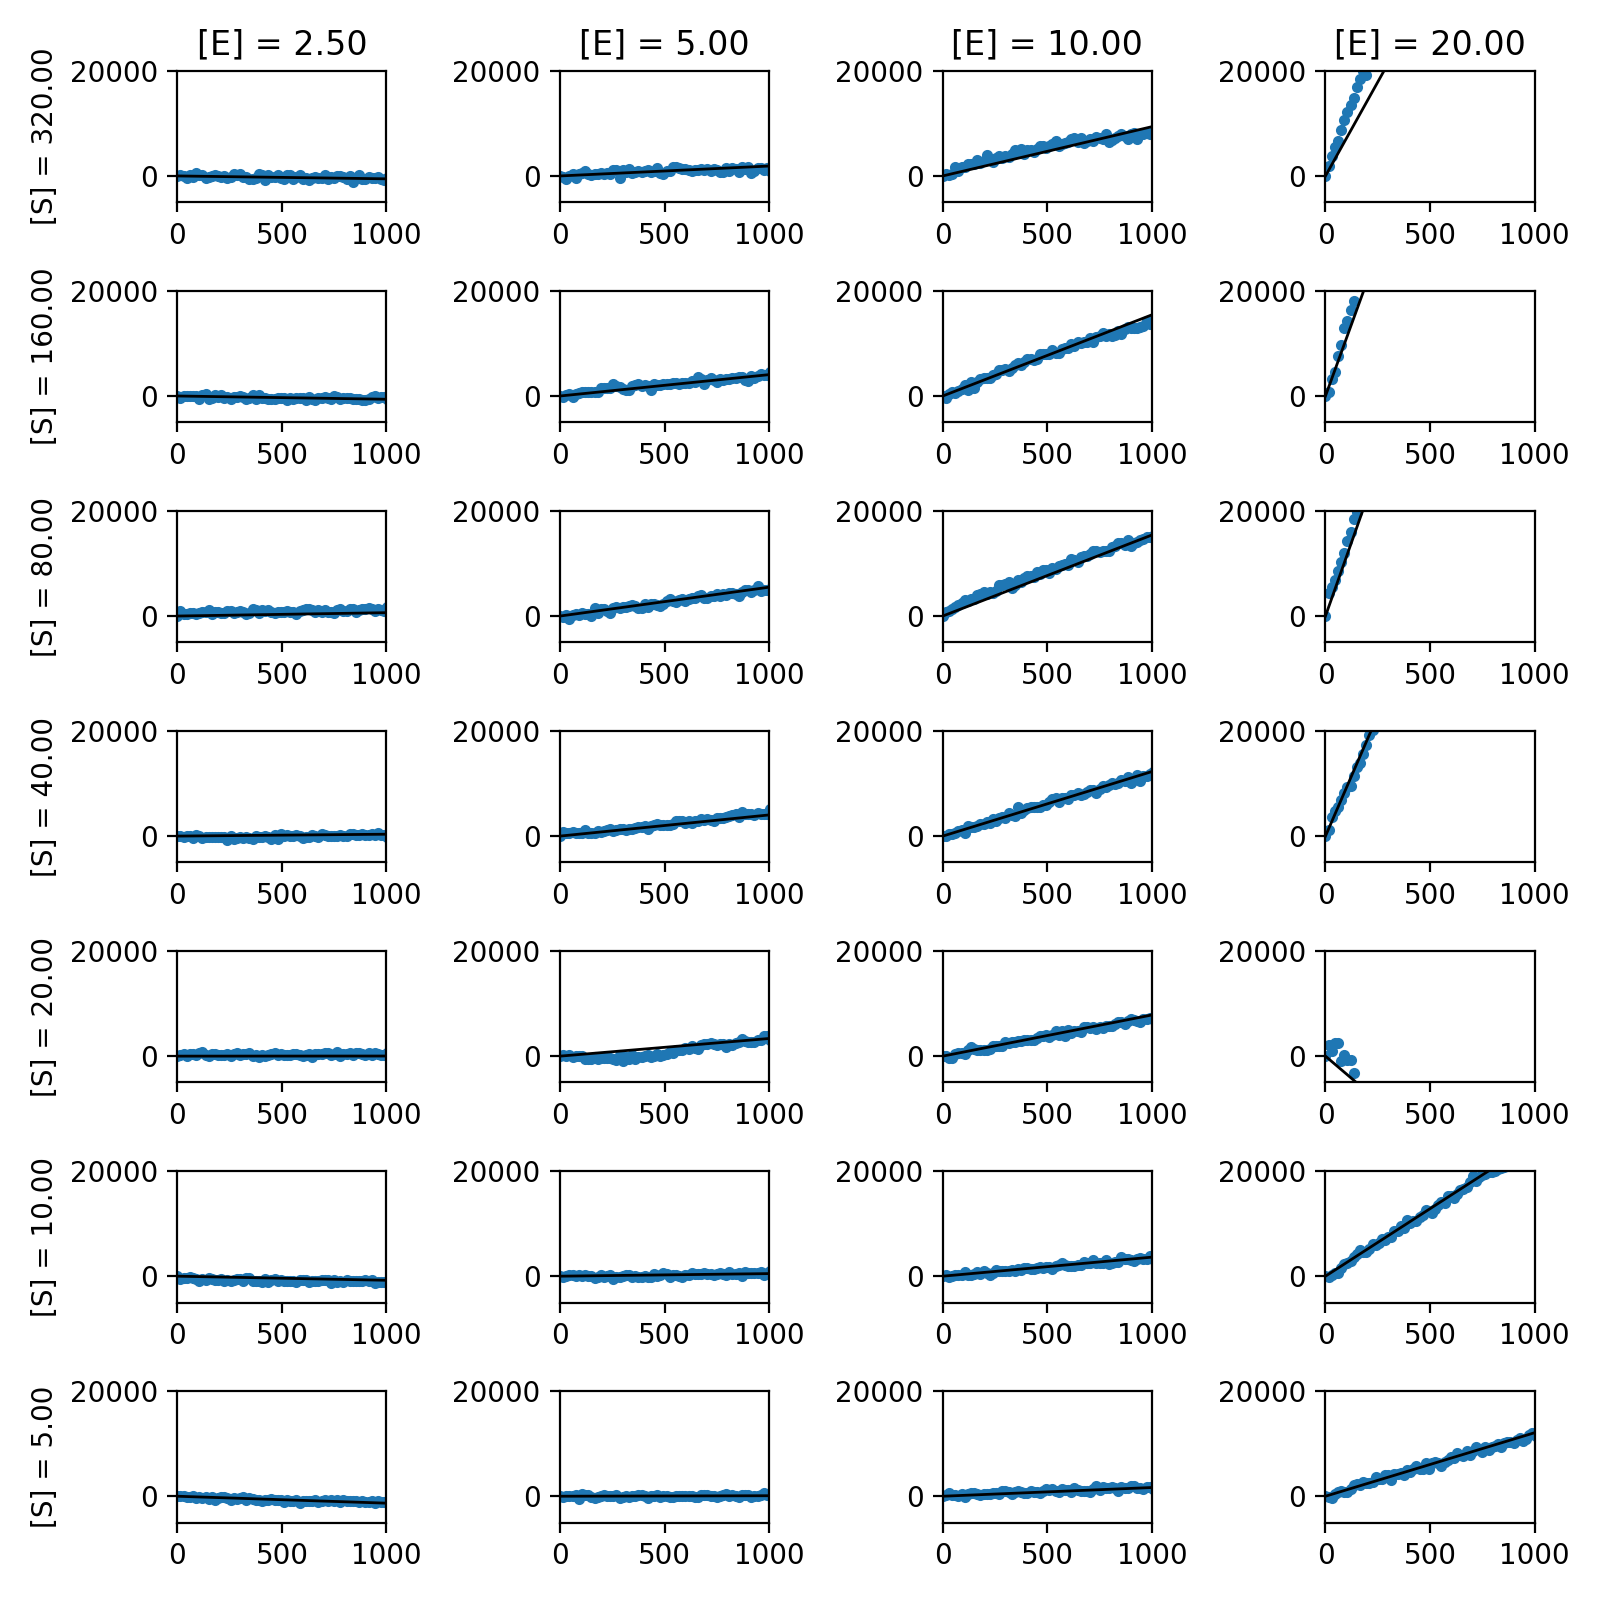

In [16]:
fig, axes = plt.subplots(n_s, n_p, figsize=(8,8))

for i_p,p in enumerate(ps):
    for i_s,s in enumerate(ss):
        
        v0_set = []
        
        for entry in ks.get(p, s):
            
            v0, b, stderr_v0, r2 = fit_linear_v0(**entry)
            
            t = entry['dt'] * np.arange(len(entry['timeseries']))
            axes[i_s, i_p].plot(t, entry['timeseries'] - entry['timeseries'][0], '.')
            axes[i_s, i_p].plot(t, v0 * t, color='k', lw=1)
            
            axes[i_s, i_p].set_xlim([0, 1000])
            axes[i_s, i_p].set_ylim([-5000, 20000])
            
            if i_s == 0:
                axes[i_s, i_p].set_title('[E] = %.2f' % p)
                
            if i_p == 0:
                axes[i_s, i_p].set_ylabel('[S] = %.2f' % s)
            
            v0_set.append(v0)
            
        
        # NOTE: here we may want to exclude, error weight, etc
        v0s[i_p, i_s] = np.mean(v0_set)
   

plt.tight_layout()
plt.savefig('figures/%s_traces.pdf' % mutant)
plt.show()

In [17]:
# QUESTIONABLE!
# seems we have a negative-drifting baseline...

v0s = v0s + 2

<IPython.core.display.Javascript object>


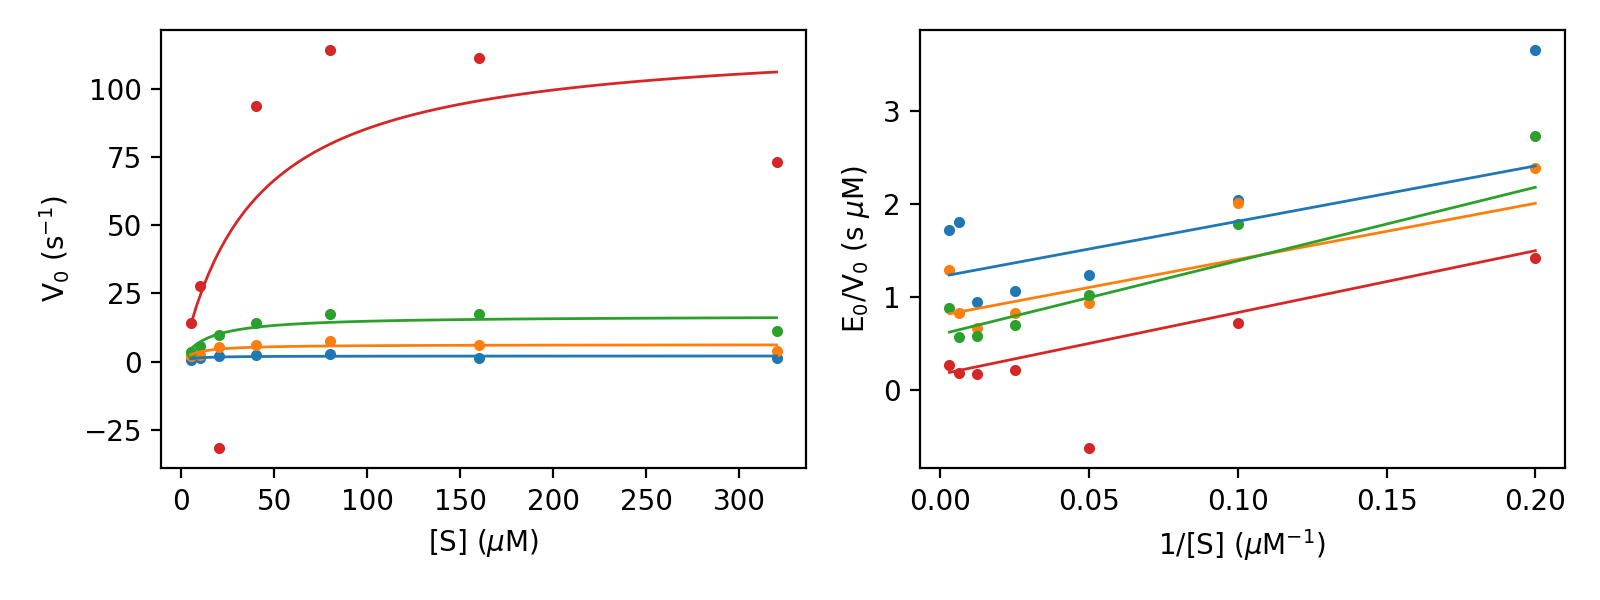

[E]	k_cat		K_m
---	-----		---
2.50	8.21e-01	4.89e+00
5.00	1.25e+00	7.54e+00
10.00	1.67e+00	1.33e+01
20.00	5.97e+00	3.97e+01


In [18]:
kinetic_params = np.zeros([n_p, 3])

plt.figure(figsize=(8,3))

ax1 = plt.subplot(121)
plt.plot(ss, v0s.T, '.')
plt.gca().set_prop_cycle(None)
plt.xlabel('[S] ($\mu$M)')
plt.ylabel('V$_0$ (s$^{-1}$)')

# Lineweaver-Burk
ax2 = plt.subplot(122)
plt.plot(1.0/np.array(ss), ps/(v0s.T), '.')
plt.gca().set_prop_cycle(None)
plt.xlabel('1/[S] ($\mu$M$^{-1}$)')
plt.ylabel('E$_0$/V$_0$ (s $\mu$M)')

# fit

print('[E]\tk_cat\t\tK_m')
print('---\t-----\t\t---')

for i,e in enumerate(ps):
    
    k_cat, K_m = fit_mm(v0s[i,:], ss, ps[i])
    print('%.2f\t%.2e\t%.2e' % (e, k_cat, K_m))
    kinetic_params[i,:] = np.array([e, k_cat, K_m])
    
    S = np.linspace(ss.min(), ss.max(), 100)
    V_fit = mm(e, S, k_cat, K_m)
    ax1.plot(S, V_fit, lw=1)
    ax2.plot(1.0/S, ps[i]/V_fit, lw=1)

plt.tight_layout()
plt.savefig('figures/%s_lineweaver_burk.pdf' % mutant)
plt.show()

<IPython.core.display.Javascript object>


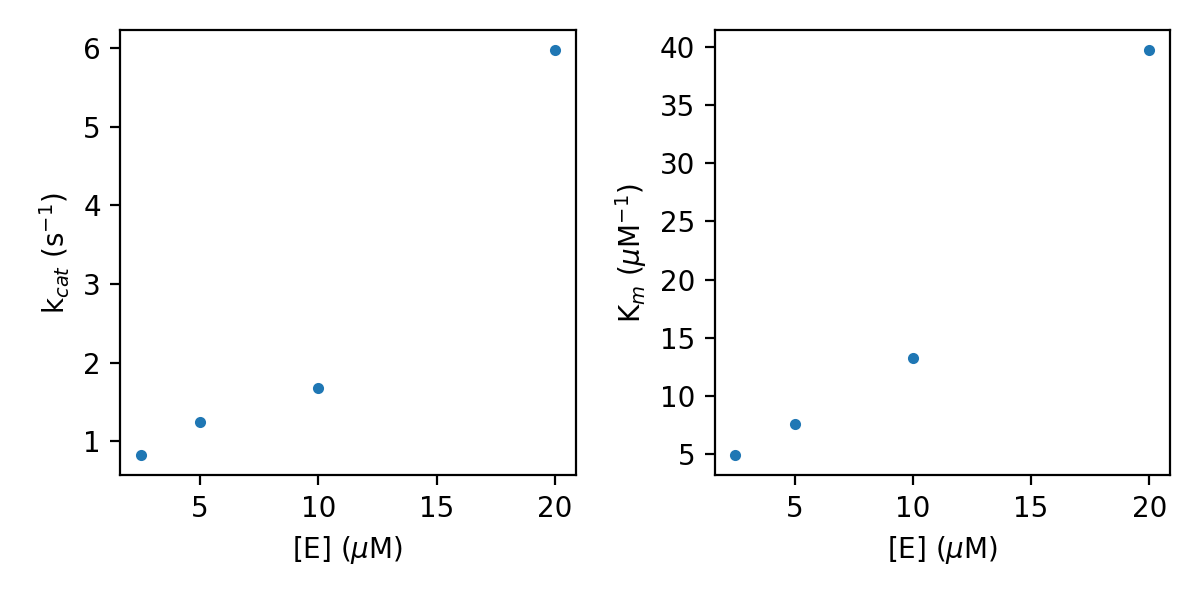

In [20]:
plt.figure(figsize=(6,3))

plt.subplot(121)
plt.plot(kinetic_params[:,0], kinetic_params[:,1], '.')
plt.xlabel('[E] ($\mu$M)')
plt.ylabel('k$_{cat}$ (s$^{-1}$)')

plt.subplot(122)
plt.plot(kinetic_params[:,0], kinetic_params[:,2], '.')
plt.xlabel('[E] ($\mu$M)')
plt.ylabel('K$_m$ ($\mu$M$^{-1}$)')

plt.tight_layout()
plt.show()

## Haldane

<IPython.core.display.Javascript object>


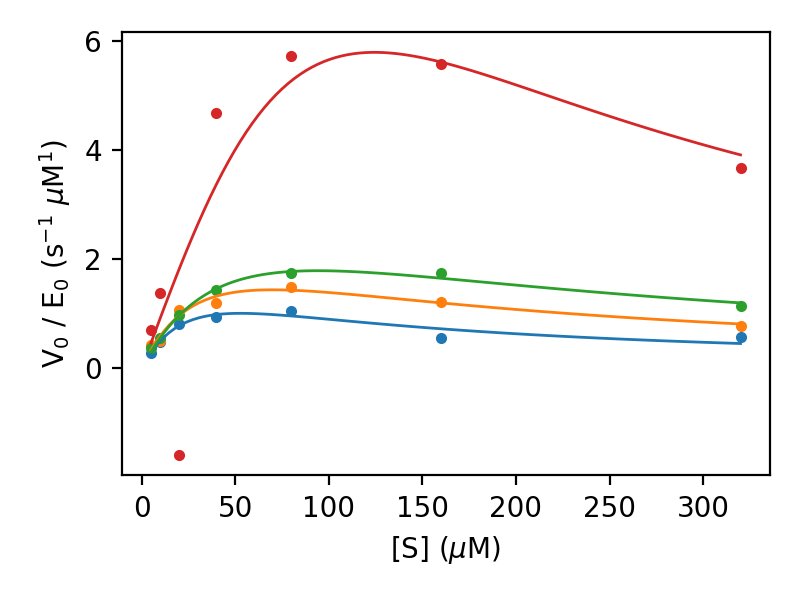

[E]	k_cat		K_m	K_i
---	-----		---	---
2.50	2.38e+00	3.60e+01	7.75e+01
5.00	3.20e+00	4.29e+01	1.14e+02
10.00	4.26e+00	6.52e+01	1.36e+02
20.00	9.93e+04	1.07e+06	1.45e-02


In [21]:
haldane_params = np.zeros([n_p, 4])

plt.figure(figsize=(4,3))

plt.plot(ss, v0s.T / ps, '.')
plt.gca().set_prop_cycle(None)
plt.xlabel('[S] ($\mu$M)')
plt.ylabel('V$_0$ / E$_0$ (s$^{-1}$ $\mu$M$^{1}$)')

# fit
print('[E]\tk_cat\t\tK_m\tK_i')
print('---\t-----\t\t---\t---')

for i,e in enumerate(ps):
    
    k_cat, K_m, K_i = fit_haldane(v0s[i,:], ss, ps[i])
    print('%.2f\t%.2e\t%.2e\t%.2e' % (e, k_cat, K_m, K_i))
    haldane_params[i,:] = np.array([e, k_cat, K_m, K_i])
    
    S = np.linspace(ss.min(), ss.max(), 100)
    V_fit = haldane(e, S, k_cat, K_m, K_i)
    plt.plot(S, V_fit / ps[i], lw=1)

plt.tight_layout()
#plt.savefig('figures/%s_haldane.pdf' % mutant)
plt.show()